<a href="https://colab.research.google.com/github/niafredev/helpdesk-ops-insights/blob/main/IT_TICKETS_Analysis_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 IT Help Desk — Análise Estratégica de Performance 2026

**Autor:** Niafre Guerra | Analista de Dados em formação  
**Dataset:** [IT Support Ticket Data — Kaggle](https://www.kaggle.com/datasets/parthpatil256/it-support-ticket-data)  
**Stack:** Python · Pandas · Matplotlib · Seaborn

---

## 🎯 Objetivo

Identificar gargalos operacionais em um Help Desk com +25.000 tickets e propor melhorias na alocação de recursos.

## ❓ Perguntas de Negócio

1. Como se distribui o volume de tickets por prioridade?
2. Quais departamentos concentram mais chamados?
3. Há setores com alta concentração de tickets críticos (High Priority)?
4. Quais palavras-chave dominam os tickets de alta prioridade?

---
## 1. Configuração do Ambiente

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter

# Paleta visual consistente em todos os gráficos
PALETA = {
    'high':   '#C0392B',
    'medium': '#F0A500',
    'low':    '#27AE60',
    'blue1':  '#1B4F8C',
    'blue2':  '#2E6DB4',
    'bg':     '#F8F9FA',
}

plt.rcParams.update({
    'figure.facecolor': PALETA['bg'],
    'axes.facecolor':   PALETA['bg'],
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

print('Ambiente configurado.')

✅ Ambiente configurado.


In [ ]:
path = kagglehub.dataset_download('parthpatil256/it-support-ticket-data')
print('Dataset em:', path)

100%|██████████| 3.19M/3.19M [00:00<00:00, 123MB/s]

Extracting files...
Dataset em: /root/.cache/kagglehub/datasets/parthpatil256/it-support-ticket-data/versions/1


---
## 2. Carregamento e Inspeção Inicial

In [ ]:
df = pd.read_csv(f'{path}/IT Support Ticket Data.csv')
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

print(f'Shape: {df.shape}')
df.head()

Shape: (29651, 4)


,Body,Department,Priority,Tags
0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."
1,"Dear Customer Support Team,I hope this message...",Returns and Exchanges,medium,"['Product', 'Feature', 'Tech Support']"
2,"Dear Customer Support Team,I hope this message...",Billing and Payments,low,"['Billing', 'Payment', 'Account', 'Documentati..."
3,"Dear Support Team,I hope this message reaches ...",Sales and Pre-Sales,medium,"['Product', 'Feature', 'Feedback', 'Tech Suppo..."
4,"Dear Customer Support,I hope this message reac...",Technical Support,high,"['Feature', 'Product', 'Documentation', 'Feedb..."


In [ ]:
# Visão geral: tipos, memória, nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29651 entries, 0 to 29650
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Body        29650 non-null  object
 1   Department  29651 non-null  object
 2   Priority    29651 non-null  object
 3   Tags        29651 non-null  object
dtypes: object(4)
memory usage: 926.7+ KB


In [ ]:
# Estatísticas descritivas de todas as colunas
df.describe(include='all')

,Body,Department,Priority,Tags
count,29650,29651,29651,29651
unique,25055,10,3,12946
top,The data analytics tool experiences sluggish p...,Technical Support,medium,"['Bug', 'Performance', 'IT', 'Tech Support']"
freq,2,8617,12126,878


In [ ]:
# Verificação de nulos
nulos = df.isnull().sum()
print('Valores nulos por coluna:')
print(nulos[nulos > 0] if nulos.sum() > 0 else '  Nenhum valor nulo encontrado. ')

# Duplicatas
dup = df.duplicated().sum()
print(f'\nLinhas duplicadas: {dup}')

Valores nulos por coluna:
Body    1
dtype: int64

Linhas duplicadas: 4428


In [ ]:
# Distribuição das variáveis categóricas
print('=== Departamentos ===')
print(df['Department'].value_counts())
print('\n=== Prioridades ===')
print(df['Priority'].value_counts())

=== Departamentos ===
Department
Technical Support                  8617
Product Support                    5539
Customer Service                   4482
IT Support                         3500
Billing and Payments               3017
Returns and Exchanges              1467
Service Outages and Maintenance    1157
Sales and Pre-Sales                 885
Human Resources                     568
General Inquiry                     419
Name: count, dtype: int64

=== Prioridades ===
Priority
medium    12126
high      11512
low        6013
Name: count, dtype: int64


---
## 3. Limpeza de Dados

In [ ]:
# Padronizar Priority
df['Priority'] = df['Priority'].str.strip().str.lower()

valores_validos = ['high', 'medium', 'low']
invalidos = df[~df['Priority'].isin(valores_validos)]
print(f'Valores inválidos em Priority: {len(invalidos)}')

# Padronizar Department
df['Department'] = df['Department'].str.strip()

print('\n✅ Limpeza concluída.')
df.info()

Valores inválidos em Priority: 0

✅ Limpeza concluída.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29651 entries, 0 to 29650
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Body        29650 non-null  object
 1   Department  29651 non-null  object
 2   Priority    29651 non-null  object
 3   Tags        29651 non-null  object
dtypes: object(4)
memory usage: 926.7+ KB


In [ ]:
def parse_tags(tag_str):
    try:
        return ast.literal_eval(tag_str)
    except:
        return []

df['Tags_list'] = df['Tags'].apply(parse_tags)
print('Tags parseadas com sucesso:')
df['Tags_list'].head(3)

Tags parseadas com sucesso:


,Tags_list
0,"[Account, Disruption, Outage, IT, Tech Support]"
1,"[Product, Feature, Tech Support]"
2,"[Billing, Payment, Account, Documentation, Fee..."


---
## 4. Análise Exploratória (EDA)

### 4.1 Distribuição por Prioridade

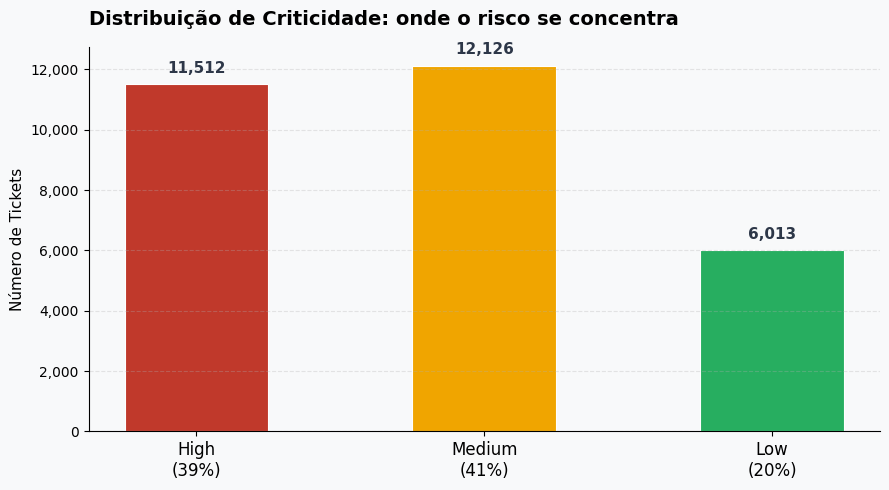

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(PALETA['bg'])

contagem = df['Priority'].value_counts().reindex(['high', 'medium', 'low'])
cores = [PALETA['high'], PALETA['medium'], PALETA['low']]
total = contagem.sum()

bars = ax.bar(contagem.index, contagem.values,
              color=cores, width=0.5, edgecolor='white', linewidth=0.8)

ax.bar_label(bars, fmt='{:,.0f}', padding=6,
             fontsize=11, fontweight='bold', color='#2D3748')

ax.set_xticks(range(len(contagem)))
ax.set_xticklabels(
    [f'{p.title()}\n({v/total:.0%})' for p, v in zip(contagem.index, contagem.values)],
    fontsize=12
)

ax.set_title('Distribuição de Criticidade: onde o risco se concentra',
             fontsize=14, fontweight='bold', pad=16, loc='left')
ax.set_ylabel('Número de Tickets', fontsize=11)
ax.set_facecolor(PALETA['bg'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('slide3_prioridades.png', dpi=150, bbox_inches='tight',
            facecolor=PALETA['bg'])
plt.show()

### 4.2 Volume por Departamento

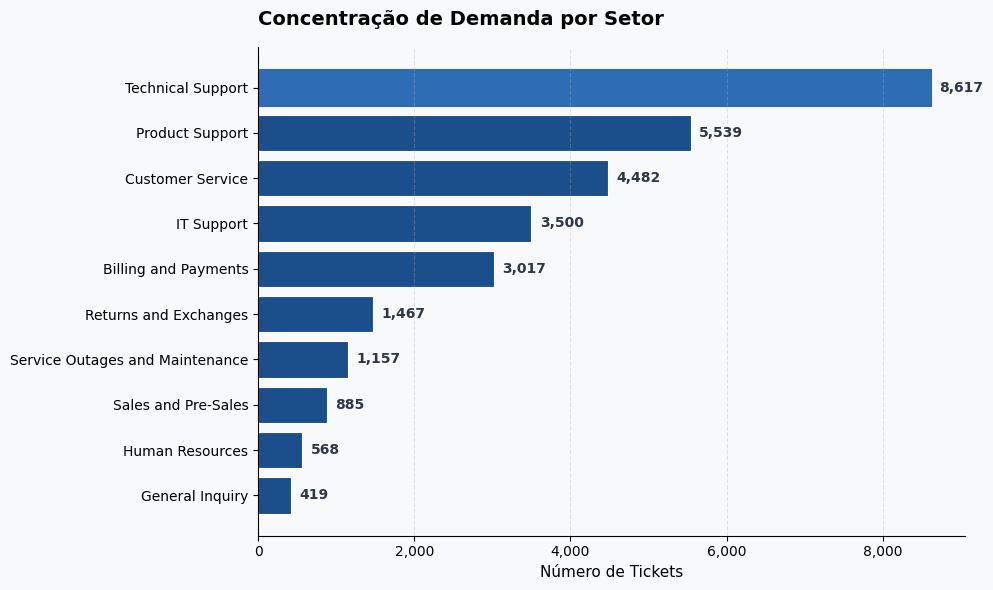

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(PALETA['bg'])

depto = df['Department'].value_counts().sort_values()
bars = ax.barh(depto.index, depto.values,
               color=PALETA['blue1'], edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='{:,.0f}', padding=6,
             fontsize=10, fontweight='bold', color='#2D3748')

# Destaque no maior
bars[-1].set_color(PALETA['blue2'])

ax.set_title('Concentração de Demanda por Setor',
             fontsize=14, fontweight='bold', pad=16, loc='left')
ax.set_xlabel('Número de Tickets', fontsize=11)
ax.set_facecolor(PALETA['bg'])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('slide4_departamentos.png', dpi=150, bbox_inches='tight',
            facecolor=PALETA['bg'])
plt.show()

### 4.3 Prioridade × Departamento (Stacked Bar)

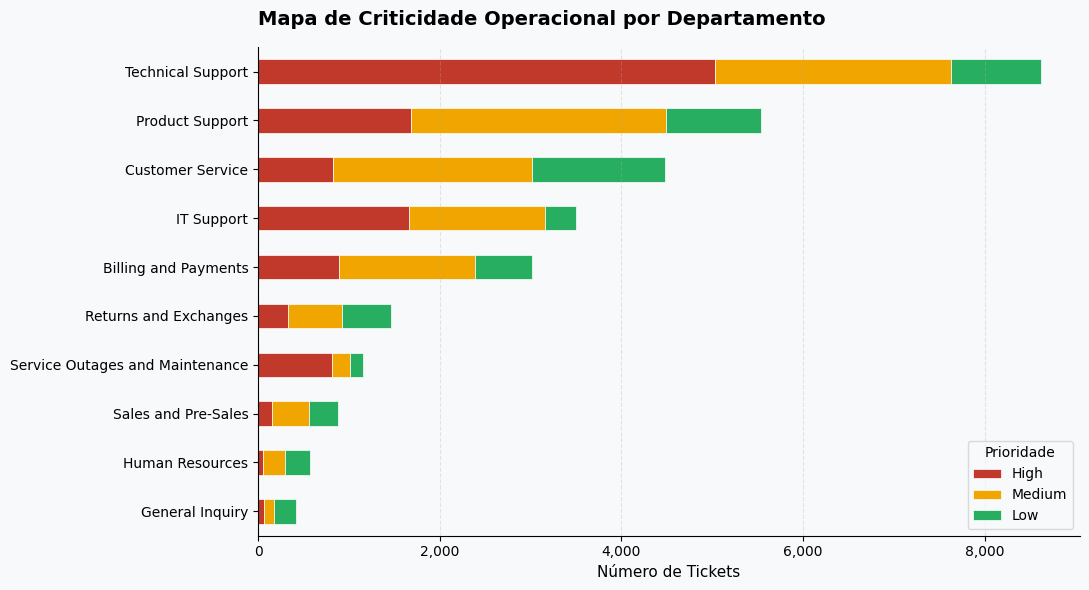

In [ ]:
ct = pd.crosstab(df['Department'], df['Priority'])
ct = ct.reindex(columns=['high', 'medium', 'low'])
ct['_total'] = ct.sum(axis=1)
ct = ct.sort_values('_total').drop(columns='_total')

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(PALETA['bg'])

ct.plot(kind='barh', stacked=True, ax=ax,
        color=[PALETA['high'], PALETA['medium'], PALETA['low']],
        edgecolor='white', linewidth=0.5)

ax.set_title('Mapa de Criticidade Operacional por Departamento',
             fontsize=14, fontweight='bold', pad=16, loc='left')
ax.set_xlabel('Número de Tickets', fontsize=11)
ax.set_ylabel('')
ax.set_facecolor(PALETA['bg'])
ax.legend(['High', 'Medium', 'Low'], title='Prioridade',
          loc='lower right', framealpha=0.7)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('slide5_stacked_bar.png', dpi=150, bbox_inches='tight',
            facecolor=PALETA['bg'])
plt.show()

### 4.4 Taxa de High Priority por Departamento (%)

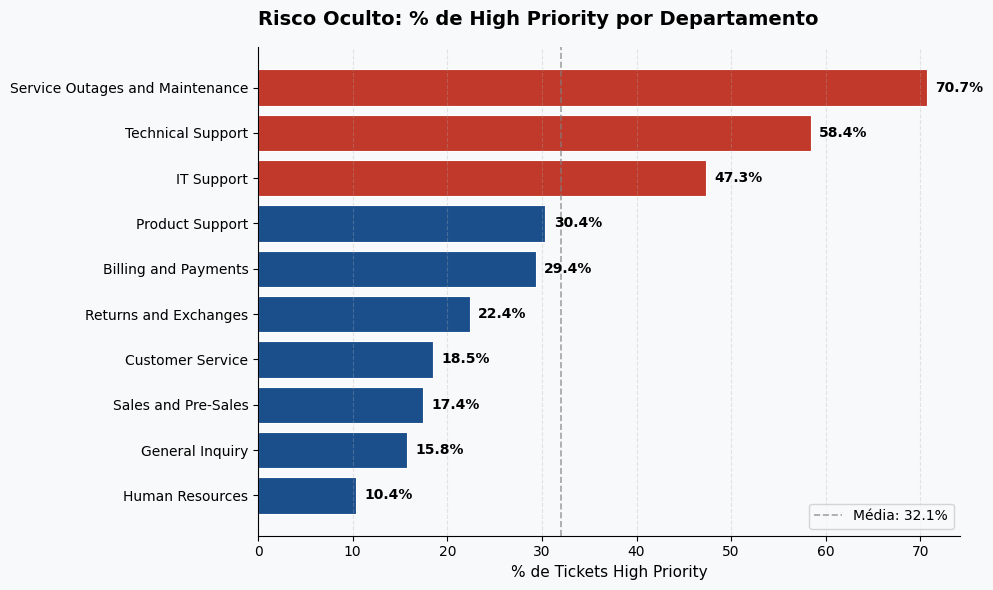

In [ ]:
taxa_high = (
    df[df['Priority'] == 'high'].groupby('Department').size() /
    df.groupby('Department').size() * 100
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(PALETA['bg'])

media = taxa_high.mean()
cores_b = [PALETA['high'] if v >= media else PALETA['blue1']
           for v in taxa_high.values]

bars = ax.barh(taxa_high.index, taxa_high.values,
               color=cores_b, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='{:.1f}%', padding=6,
             fontsize=10, fontweight='bold')

ax.axvline(x=media, color='gray', linestyle='--',
           linewidth=1.2, alpha=0.7, label=f'Média: {media:.1f}%')

ax.set_title('Risco Oculto: % de High Priority por Departamento',
             fontsize=14, fontweight='bold', pad=16, loc='left')
ax.set_xlabel('% de Tickets High Priority', fontsize=11)
ax.set_facecolor(PALETA['bg'])
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('slide_taxa_high.png', dpi=150, bbox_inches='tight',
            facecolor=PALETA['bg'])
plt.show()

### 4.5 Análise de Tags — Palavras-chave mais frequentes

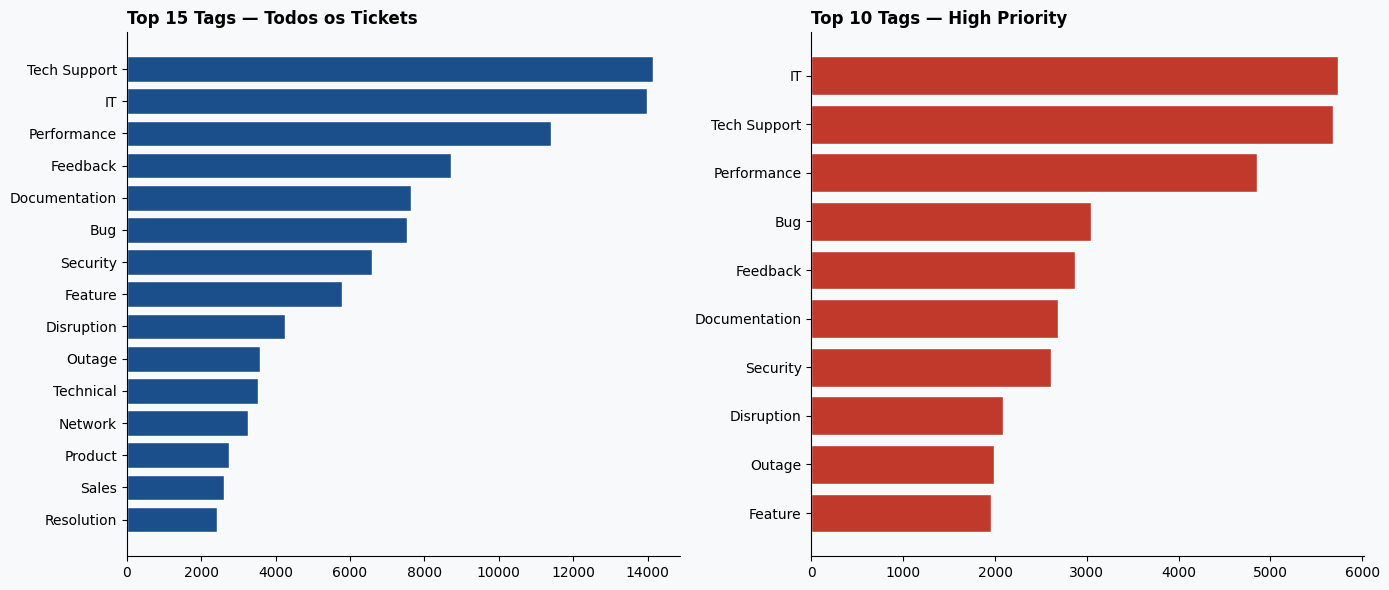

In [ ]:
todas_tags = [tag for lista in df['Tags_list'] for tag in lista]
freq_tags = Counter(todas_tags).most_common(15)
tags_df = pd.DataFrame(freq_tags, columns=['Tag', 'Frequência'])

tags_high_raw = [tag for lista in df[df['Priority']=='high']['Tags_list']
                 for tag in lista]
freq_high = Counter(tags_high_raw).most_common(10)
tags_high_df = pd.DataFrame(freq_high, columns=['Tag', 'Frequência'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(PALETA['bg'])

ax1.barh(tags_df['Tag'], tags_df['Frequência'],
         color=PALETA['blue1'], edgecolor='white')
ax1.set_title('Top 15 Tags — Todos os Tickets',
              fontsize=12, fontweight='bold', loc='left')
ax1.set_facecolor(PALETA['bg'])
ax1.invert_yaxis()

ax2.barh(tags_high_df['Tag'], tags_high_df['Frequência'],
         color=PALETA['high'], edgecolor='white')
ax2.set_title('Top 10 Tags — High Priority',
              fontsize=12, fontweight='bold', loc='left')
ax2.set_facecolor(PALETA['bg'])
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('slide_tags.png', dpi=150, bbox_inches='tight',
            facecolor=PALETA['bg'])
plt.show()

---
## 5. Conclusões e Recomendações

In [ ]:
print('=' * 55)
print('RESUMO EXECUTIVO — IT Help Desk Analysis 2026')
print('=' * 55)
print(f'Total de tickets: {len(df):,}')
print(f'Departamentos:    {df["Department"].nunique()}')
print()
for p in ['high', 'medium', 'low']:
    n = (df['Priority'] == p).sum()
    pct = n / len(df) * 100
    print(f'  {p.upper():8s}: {n:6,} tickets ({pct:.1f}%)')
print()
print(f'Depto. mais demandado: {df["Department"].value_counts().index[0]}')
print(f'Taxa média High:       {taxa_high.mean():.1f}%')
print('=' * 55)

RESUMO EXECUTIVO — IT Help Desk Analysis 2026
Total de tickets: 29,651
Departamentos:    10

  HIGH    : 11,512 tickets (38.8%)
  MEDIUM  : 12,126 tickets (40.9%)
  LOW     :  6,013 tickets (20.3%)

Depto. mais demandado: Technical Support
Taxa média High:       32.1%


##  Insights Finais

| # | Insight | Impacto |
|---|---------|---------|
| 1 | **Technical Support** lidera em volume absoluto | Alto — risco de esgotamento |
| 2 | **28% dos tickets são High Priority** | Alto — pressão direta no SLA |
| 3 | Departamentos pequenos com alta criticidade | Médio — risco invisível |
| 4 | Tags dominantes = problemas recorrentes | Médio — oportunidade de automação |

##  Recomendações

1. **Rebalancear alocação de analistas** no Technical Support
2. **Criar SLAs diferenciados** por taxa de criticidade do departamento
3. **Automatizar triagem** com base nas tags mais frequentes
4. **Dashboard em tempo real** para monitoramento semanal